In [513]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import locale

PHASE 1: DATA CLEAN-UP

In [514]:
# loading dataset
data = pd.read_csv("./datasets/housing.csv")
dataset = data.drop(columns=["prefarea", "price"])
print("🔻DATASET HEAD BEFORE: \n", dataset.head(3), "\n")

# numerizing dataset
dataset["furnishingstatus"] = dataset["furnishingstatus"].map({'furnished': 1, 'semi-furnished': 0.5, 'unfurnished': 0}) 

yn_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning"]
for col in yn_cols:
    dataset[col] = dataset[col].map({'yes': 1, 'no': 0})
    
print("🔻DATASET HEAD AFTER: \n", dataset.head(3), "\n")


🔻DATASET HEAD BEFORE: 
    area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  7420         4          2        3      yes        no       no   
1  8960         4          4        4      yes        no       no   
2  9960         3          2        2      yes        no      yes   

  hotwaterheating airconditioning  parking furnishingstatus  
0              no             yes        2        furnished  
1              no             yes        3        furnished  
2              no              no        2   semi-furnished   

🔻DATASET HEAD AFTER: 
    area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
0  7420         4          2        3         1          0         0   
1  8960         4          4        4         1          0         0   
2  9960         3          2        2         1          0         1   

   hotwaterheating  airconditioning  parking  furnishingstatus  
0                0                1        2               1.0  
1      

PHASE 2: CREATE & ANALYZE GRAPH

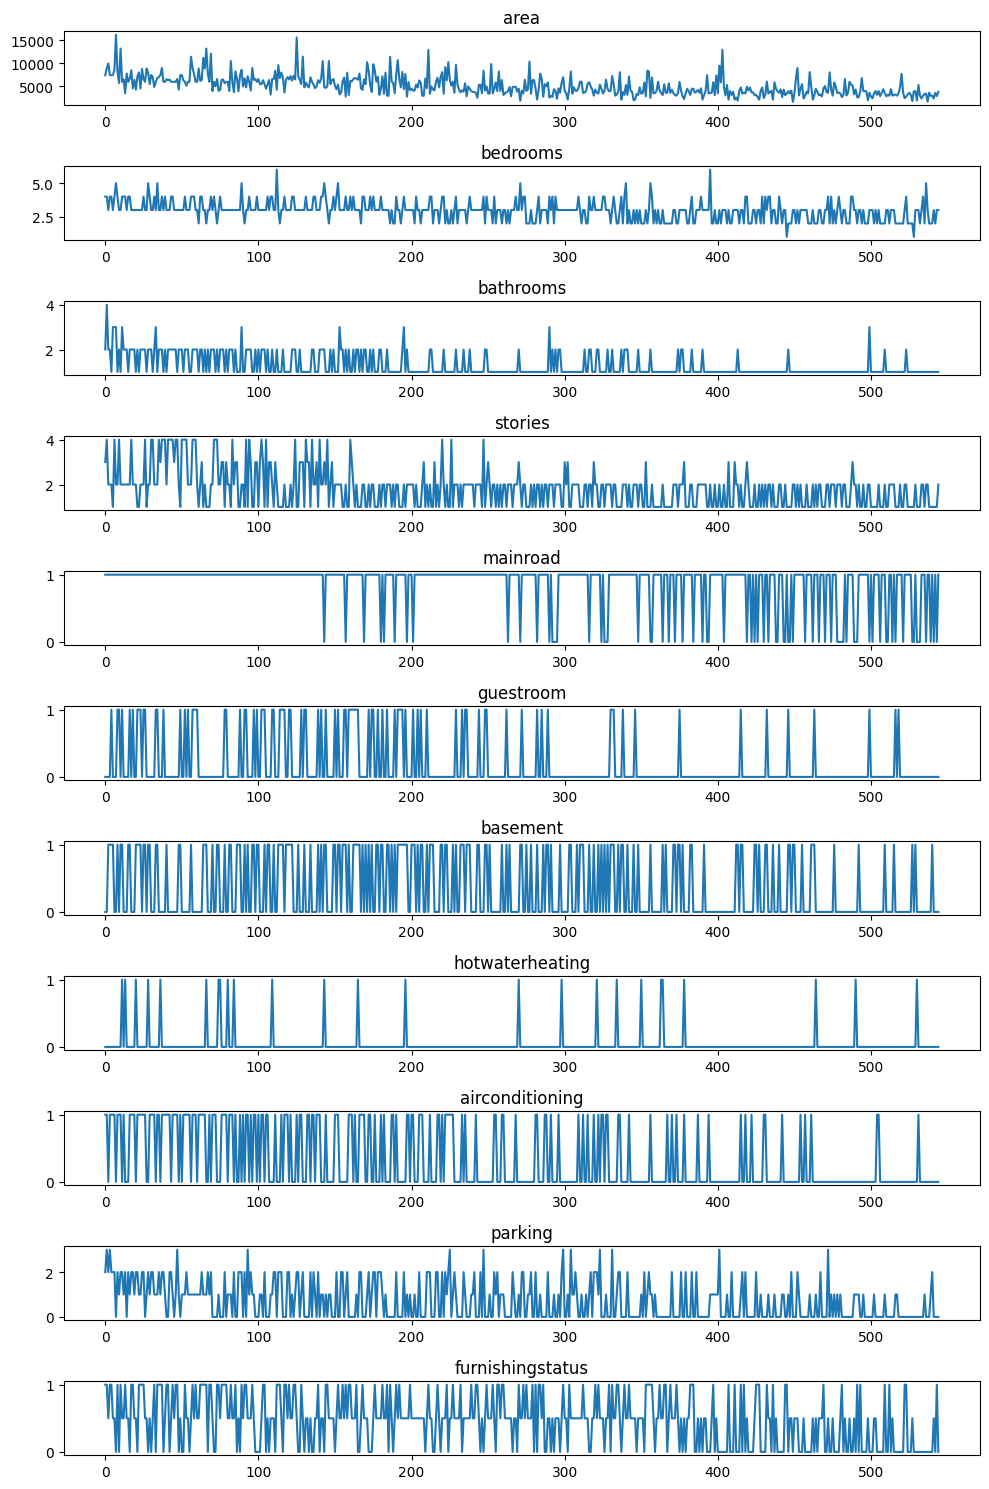

In [515]:
sample_count = len(dataset)
feature_count = len(dataset.iloc[0])
cols_name = list(dataset.columns)

fig, axes = plt.subplots(len(cols_name), 1, figsize=(10, 15))

for i, col in enumerate(cols_name):
    axes[i].plot(dataset.index, dataset[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

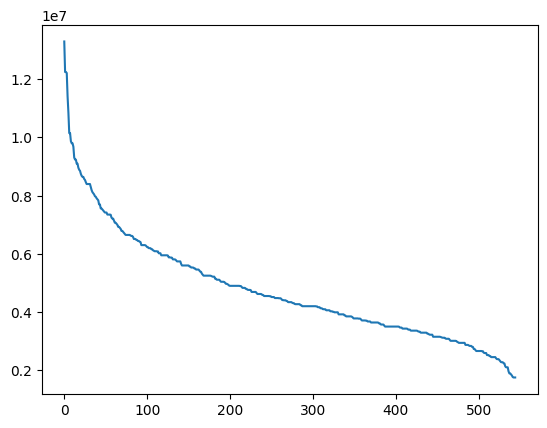

In [516]:
plt.plot(data.index, data["price"])
plt.show()

PHASE 3: Feature Scaling

In [517]:
dataset_max = list(dataset.max())
truth_max = data["price"].max()

x = dataset / dataset_max
y = list(data["price"] / truth_max)

x = torch.tensor(x.values, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

y = torch.unsqueeze(y, 1)

PHASE 4: Creating & Instantiating Model Class

In [518]:
class HousePricing(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(list(x.size())[1], 1)
        
    def forward(self, x):
        return self.linear(x)

# hyperparameters (i guess)
learning_rate = 5e-2
epochs = 1000

# instantiations
model = HousePricing()
loss = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

PHASE 5: Training

In [519]:
for epoch in range(epochs):
    output = model(x)
    
    l = loss(output, y)
    
    l.backward()
    
    optimizer.step()
    optimizer.zero_grad()   
    
    print(f"epoch {epoch} = loss: {l}")
    

epoch 0 = loss: 0.22260229289531708
epoch 1 = loss: 0.08266221731901169
epoch 2 = loss: 0.07003309577703476
epoch 3 = loss: 0.10416758805513382
epoch 4 = loss: 0.10970424860715866
epoch 5 = loss: 0.08475609868764877
epoch 6 = loss: 0.05297093465924263
epoch 7 = loss: 0.0330205112695694
epoch 8 = loss: 0.030672678723931313
epoch 9 = loss: 0.038861509412527084
epoch 10 = loss: 0.04522661119699478
epoch 11 = loss: 0.04249080270528793
epoch 12 = loss: 0.032118845731019974
epoch 13 = loss: 0.020622247830033302
epoch 14 = loss: 0.014151240698993206
epoch 15 = loss: 0.014793479815125465
epoch 16 = loss: 0.0198490209877491
epoch 17 = loss: 0.02431217022240162
epoch 18 = loss: 0.024696974083781242
epoch 19 = loss: 0.02110576443374157
epoch 20 = loss: 0.016379578039050102
epoch 21 = loss: 0.013661914505064487
epoch 22 = loss: 0.014244606718420982
epoch 23 = loss: 0.016943050548434258
epoch 24 = loss: 0.019263021647930145
epoch 25 = loss: 0.019373636692762375
epoch 26 = loss: 0.017303209751844406

PHASE 7: Evaluation

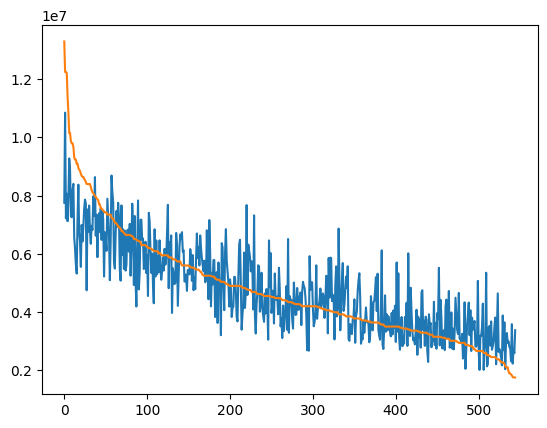

In [520]:
prices_linear = []
index = []

for i in range(sample_count):
    test_data = x[i]
    test_output = model(test_data)
    test_output = test_output[0].tolist()
    test_output = round(test_output * truth_max)
    prices_linear.append(test_output)
    index.append(i)

plt.plot(index, prices_linear)
plt.plot(index, data["price"])
plt.show()

In [521]:
area = 3850
bedrooms = 3
bathrooms = 1
stories = 2
mainroad = 1
guestroom = 0
basement = 0
hotwaterheating = 0
airconditioning = 0
parking = 0
furnishingstatus = 0

test_data = torch.tensor([[area, bedrooms, bathrooms, stories, mainroad, guestroom, basement, hotwaterheating, airconditioning, parking, furnishingstatus]], dtype=torch.float32)
data_max_tensor = torch.tensor([dataset_max])

test_data = test_data / data_max_tensor

test_output = model(test_data)
test_output = test_output[0, 0].tolist()
test_output = round(test_output * truth_max)

locale.setlocale(locale.LC_ALL, 'en_US.UTF-8')
print(locale.currency(test_output, grouping=True), "\n")
print(model.linear.weight)

$3,375,362.00 

Parameter containing:
tensor([[0.3238, 0.0576, 0.2933, 0.1389, 0.0394, 0.0247, 0.0356, 0.0605, 0.0656,
         0.0621, 0.0335]], requires_grad=True)


its not accurate but well.. lets try using hidden thoughts and activation function

In [550]:
feature_count = list(x.size())[1]

class HousePricing2(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(feature_count, feature_count ** 2)
        self.linear2 = nn.Linear(feature_count ** 2, 1)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        return x
    

model2 = HousePricing2()
loss2 = nn.MSELoss()
optimizer2 = torch.optim.Adam(model2.parameters(), lr=1.8e-2)


In [551]:
for epoch in range(2000):
    output = model2(x)
    
    l = loss2(output, y)
    
    l.backward()
    
    optimizer2.step()
    optimizer2.zero_grad()
    
    print(f"epoch {epoch} = loss: {l}")    

epoch 0 = loss: 0.19290588796138763
epoch 1 = loss: 0.05290260538458824
epoch 2 = loss: 0.10616748034954071
epoch 3 = loss: 0.042704999446868896
epoch 4 = loss: 0.013935484923422337
epoch 5 = loss: 0.02391839027404785
epoch 6 = loss: 0.037853557616472244
epoch 7 = loss: 0.03983112797141075
epoch 8 = loss: 0.031247761100530624
epoch 9 = loss: 0.0193825401365757
epoch 10 = loss: 0.011097409762442112
epoch 11 = loss: 0.010000606067478657
epoch 12 = loss: 0.014966600574553013
epoch 13 = loss: 0.020234305411577225
epoch 14 = loss: 0.020799187943339348
epoch 15 = loss: 0.016995064914226532
epoch 16 = loss: 0.012267330661416054
epoch 17 = loss: 0.009581378661096096
epoch 18 = loss: 0.009683712385594845
epoch 19 = loss: 0.011465026065707207
epoch 20 = loss: 0.013304037041962147
epoch 21 = loss: 0.014049066230654716
epoch 22 = loss: 0.013374404050409794
epoch 23 = loss: 0.011703974567353725
epoch 24 = loss: 0.009890680201351643
epoch 25 = loss: 0.008792063221335411
epoch 26 = loss: 0.0088256467

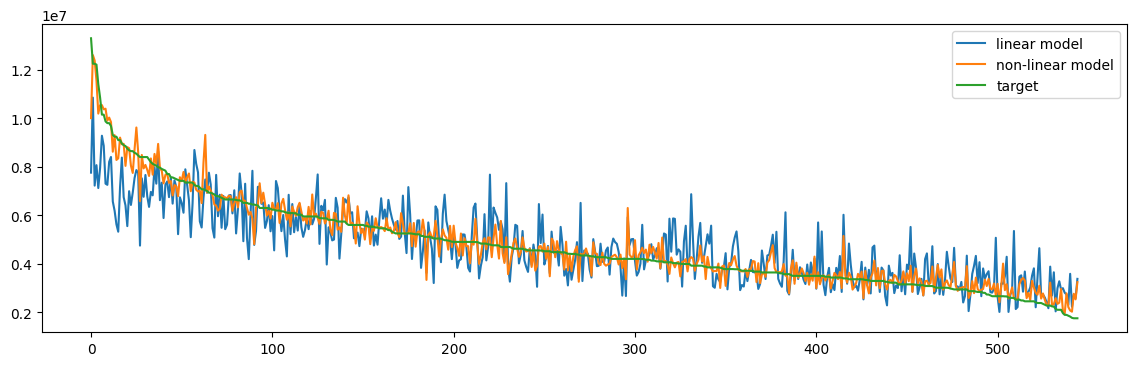

In [552]:
prices_nonlinear = []
index = []

for i in range(sample_count):
    test_data = x[i]
    test_output2 = model2(test_data)
    test_output2 = test_output2[0].tolist()
    test_output2 = round(test_output2 * truth_max)
    prices_nonlinear.append(test_output2)
    index.append(i)

plt.figure(figsize=(14, 4))
plt.plot(index, prices_linear, label="linear model")
plt.plot(index, prices_nonlinear, label="non-linear model")
plt.plot(index, data["price"], label="target")
plt.legend()
plt.show()

### linear model: built with one linear layer
### non-linear model: built with 2 linear layer, feature ** 2 hidden neurons and ReLU
both model uses Adam optimizer and i have tweak the epoch and learning rate to the maximum.

In [588]:
area = 7500
bedrooms = 0
bathrooms = 15
stories = 3
mainroad = 1
guestroom = 1
basement = 1
hotwaterheating = 1
airconditioning = 1
parking = 1
furnishingstatus = 1

test_data = torch.tensor([[area, bedrooms, bathrooms, stories, mainroad, guestroom, basement, hotwaterheating, airconditioning, parking, furnishingstatus]], dtype=torch.float32)
data_max_tensor = torch.tensor([dataset_max])

test_data = test_data / data_max_tensor

linear_output = round(model(test_data)[0, 0].tolist() * truth_max)
nonlinear_output = round(model2(test_data)[0, 0].tolist() * truth_max)

locale.setlocale(locale.LC_ALL, 'en_US.UTF-8')

print("linear model prediction: ", locale.currency(linear_output, grouping=True), "\n")
print("nonlinear model prediction: ", locale.currency(nonlinear_output, grouping=True), "\n")

linear model prediction:  $21,276,035.00 

nonlinear model prediction:  $12,402,267.00 



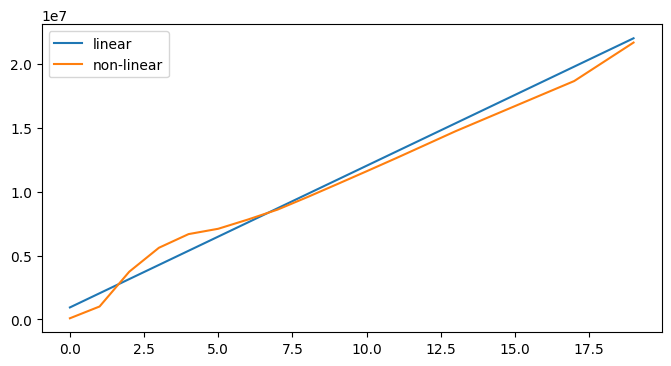

In [630]:
area = 3500
bedrooms = 0
bathrooms = 0
stories = 1
mainroad = 0
guestroom = 0
basement = 0
hotwaterheating = 0
airconditioning = 0
parking = 0
furnishingstatus = 0

lin_res = []
nlin_res = []
index = []

for i in range(20):
    test_data = torch.tensor([[area, bedrooms, bathrooms, stories, mainroad, guestroom, basement, hotwaterheating, airconditioning, parking, furnishingstatus]], dtype=torch.float32) / data_max_tensor
    
    linear_output = round(model(test_data)[0, 0].tolist() * truth_max)
    nonlinear_output = round(model2(test_data)[0, 0].tolist() * truth_max)
    
    lin_res.append(linear_output)
    nlin_res.append(nonlinear_output)
    index.append(i)
    
    area += 500
    bathrooms += 1
    
plt.figure(figsize=(8, 4)) 
plt.plot(index, lin_res, label="linear")
plt.plot(index, nlin_res, label="non-linear")
plt.legend()
plt.show()